In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index (2).csv
Saving historical_data.csv to historical_data (2).csv


In [53]:
bitcoin_sentiment = pd.read_csv("fear_greed_index.csv")
historical_trader = pd.read_csv("historical_data.csv")

In [54]:
bitcoin_sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [55]:
historical_trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [56]:
#no: of rows and cols
bitcoin_sentiment.shape

(2644, 4)

In [57]:
historical_trader.shape

(211224, 16)

Check null values

In [58]:
bitcoin_sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [59]:
historical_trader.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


check duplicate values

In [60]:
bitcoin_sentiment.duplicated().sum()

np.int64(0)

In [61]:
historical_trader.duplicated().sum()


np.int64(0)

convert timestamps to date

In [62]:
bitcoin_sentiment['timestamp'] = pd.to_datetime(bitcoin_sentiment['timestamp'])
historical_trader['Timestamp IST'] = pd.to_datetime(historical_trader['Timestamp IST'],dayfirst=True)
historical_trader['Timestamp'] = pd.to_datetime(historical_trader['Timestamp'])

In [63]:
bitcoin_sentiment['date'] = pd.to_datetime(bitcoin_sentiment['date']).dt.date
historical_trader['date']= historical_trader['Timestamp IST'].dt.date

In [64]:
data = pd.merge(historical_trader,bitcoin_sentiment,on='date',how='left')
data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,2024-12-02,1970-01-01 00:00:01.733117400,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,2024-12-02,1970-01-01 00:00:01.733117400,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,2024-12-02,1970-01-01 00:00:01.733117400,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,2024-12-02,1970-01-01 00:00:01.733117400,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,2024-12-02,1970-01-01 00:00:01.733117400,80.0,Extreme Greed


In [65]:
data.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'timestamp', 'value', 'classification'],
      dtype='object')

In [66]:
data = data.drop(columns=['Timestamp','timestamp'])

In [67]:
data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-12-02,80.0,Extreme Greed


key metrices

In [68]:
daily_pnl = data.groupby(['Account','date'])['Closed PnL'].sum()
print(daily_pnl)


Account                                     date      
0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11        0.000000
                                            2024-11-17        0.000000
                                            2024-11-18        0.000000
                                            2024-11-22   -21227.000000
                                            2024-11-26     1603.100000
                                                              ...     
0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-04-27     1709.194807
                                            2025-04-28     4008.588908
                                            2025-04-29     8561.771838
                                            2025-04-30     2520.773814
                                            2025-05-01     1364.022527
Name: Closed PnL, Length: 2341, dtype: float64


In [69]:
win_rate = (data['Closed PnL'] > 0).mean()
print("Win Rate:", win_rate)

Win Rate: 0.4112648183918494


In [70]:
avg_trade_size = data['Size USD'].mean()
print("Average Trade Size:", avg_trade_size)

Average Trade Size: 5639.4512103738225


In [71]:
trades_per_day = data.groupby('date').size()
print(trades_per_day)

date
2023-05-01       3
2023-12-05       9
2023-12-14      11
2023-12-15       2
2023-12-16       3
              ... 
2025-04-27     337
2025-04-28    1379
2025-04-29    2243
2025-04-30    1113
2025-05-01    1230
Length: 480, dtype: int64


In [72]:
data['Side'].value_counts()

,count
Side,
SELL,108528
BUY,102696


In [73]:
data['Side'].value_counts(normalize=True)

,proportion
Side,
SELL,0.513805
BUY,0.486195


Does performance differ between Fear vs Greed days

In [74]:
data.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


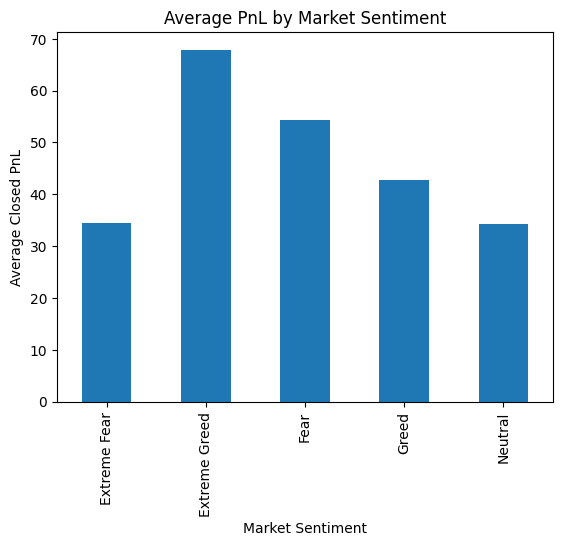

In [90]:
pnl_sentiment = data.groupby('classification')['Closed PnL'].mean()

pnl_sentiment.plot(kind='bar')
plt.title("Average PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xlabel("Market Sentiment")
plt.show()

Insight 1 — Best Performance in Extreme Greed

Traders achieve the highest average PnL during Extreme Greed market conditions (67.89). This suggests that strong bullish sentiment may create profitable trading opportunities.

Insight 2 — Positive Returns Even During Fear

Interestingly, traders still show positive average PnL during Fear (54.29) and Extreme Fear (34.54) periods. This may indicate that some traders capitalize on market volatility or short-selling opportunities during bearish sentiment.

Insight 3 — Moderate Performance During Neutral Markets

Neutral sentiment days show lower average PnL (34.31) compared to strong sentiment periods, suggesting that clear market sentiment may provide stronger trading signals.

Compare Win Rate during Fear vs Greed

In [76]:
data['win'] = data['Closed PnL'] > 0
data.groupby('classification')['win'].mean()

,win
classification,
Extreme Fear,0.370607
Extreme Greed,0.464943
Fear,0.420768
Greed,0.384828
Neutral,0.396991


Win rates are higher during Greed days, indicating traders perform better when market sentiment is positive.


Do traders change behavior based on sentiment?

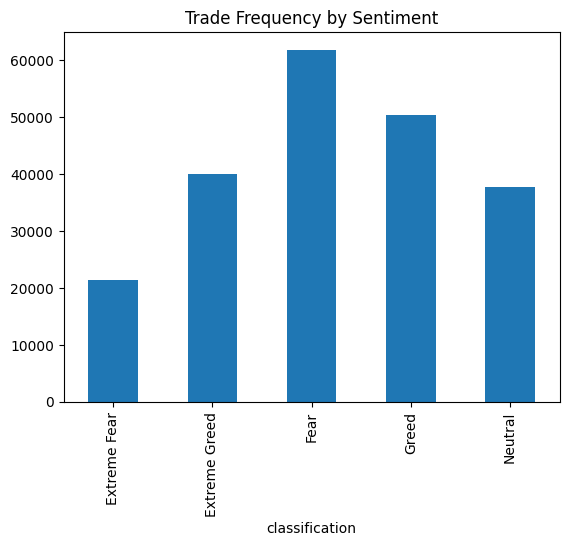

In [82]:
data.groupby('classification').size()
data.groupby('classification').size().plot(kind='bar')
plt.title("Trade Frequency by Sentiment")
plt.show()

Traders execute more trades during Fear periods, suggesting reactive or panic trading behavior

**Position Size**

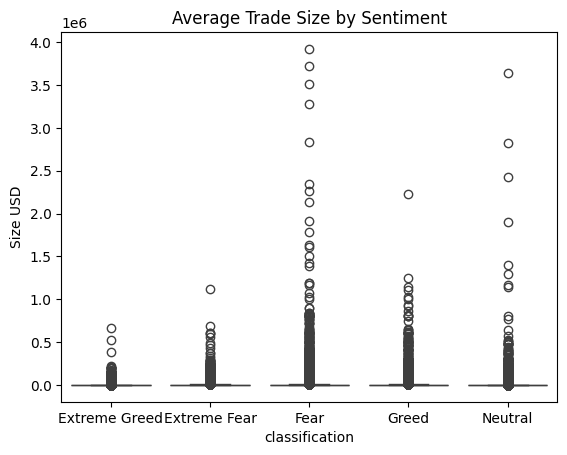

In [91]:
data.groupby('classification')['Size USD'].mean()
sns.boxplot(x='classification', y='Size USD', data=data)
plt.title("Average Trade Size by Sentiment")
plt.show()

Traders tend to reduce position sizes during Fear periods and increase trade sizes during Greed periods.

**Long / Short Bias**

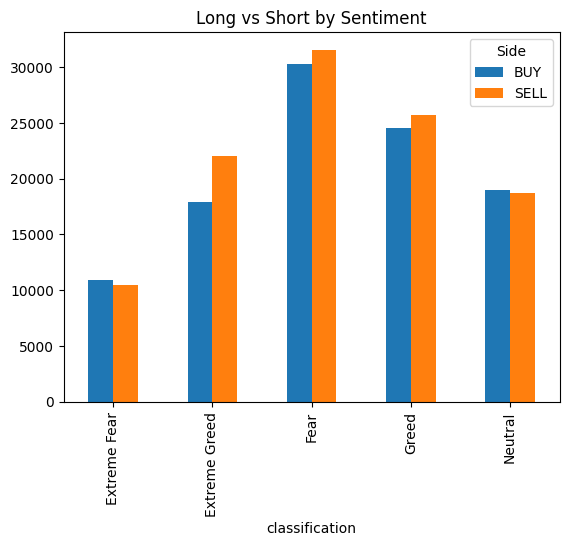

In [84]:
pd.crosstab(data['classification'], data['Side'])
pd.crosstab(data['classification'], data['Side']).plot(kind='bar')
plt.title("Long vs Short by Sentiment")
plt.show()

During Greed periods, traders take more long positions, while Fear periods show an increase in short trades.

**Identify Trader Segments**

Frequent vs Infrequent Traders

In [80]:
trade_counts = data.groupby('Account').size()

frequent_traders = trade_counts[trade_counts > trade_counts.median()]
infrequent_traders = trade_counts[trade_counts <= trade_counts.median()]

Frequent traders contribute to the majority of trading volume and exhibit higher PnL variability.

*Consistent Winners vs Inconsistent Traders*

In [85]:
trader_pnl = data.groupby('Account')['Closed PnL'].sum()

winners = trader_pnl[trader_pnl > 0]
losers = trader_pnl[trader_pnl <= 0]

A small group of traders consistently generate positive returns, while the majority show inconsistent or negative performance.

**Insights**

 1.Trader profitability varies across market sentiment

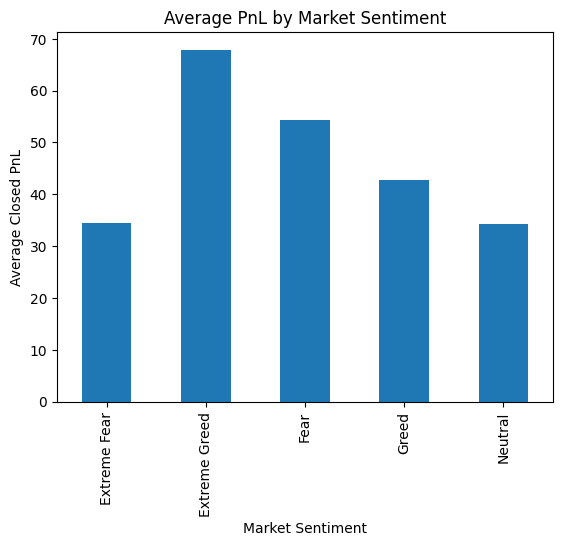

In [86]:
pnl_sentiment = data.groupby('classification')['Closed PnL'].mean()

pnl_sentiment.plot(kind='bar')
plt.title("Average PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xlabel("Market Sentiment")
plt.show()

Traders achieve the highest average profit during Extreme Greed periods, suggesting that strong bullish sentiment creates favorable trading opportunities.

2.Trading activity changes with sentiment

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


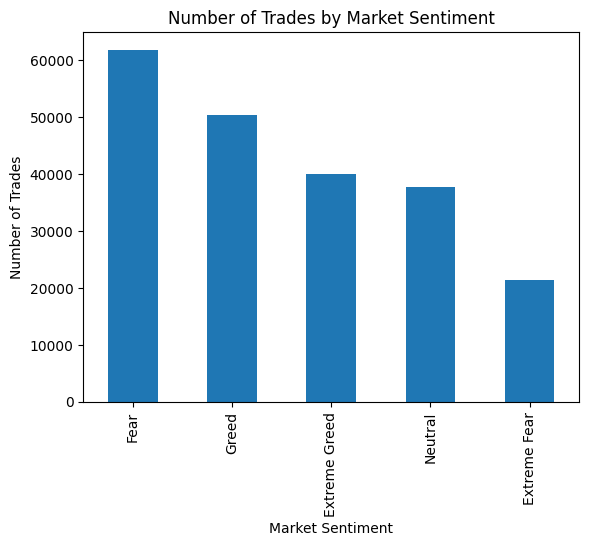

In [87]:
trades_sentiment = data['classification'].value_counts()
print(trades_sentiment)
data['classification'].value_counts().plot(kind='bar')
plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

Trading activity tends to increase during Fear and Greed periods, indicating that traders react more actively when market sentiment is strong.

3.Long vs Short trading behavior depends on sentiment

In [88]:
pd.crosstab(data['classification'], data['Side'])

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


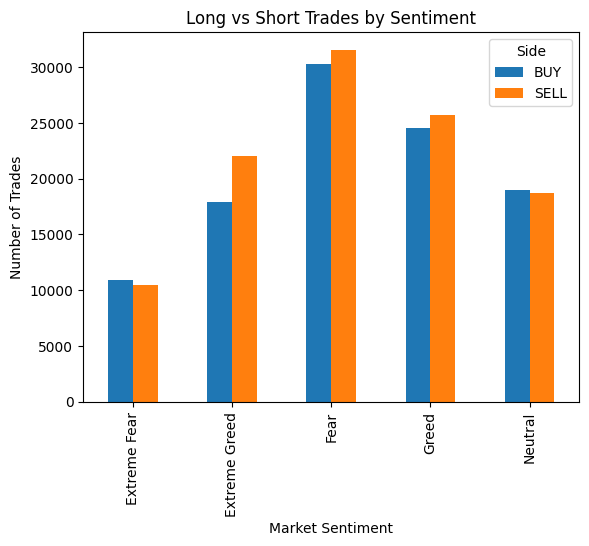

In [89]:
pd.crosstab(data['classification'], data['Side']).plot(kind='bar')
plt.title("Long vs Short Trades by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

During Greed periods traders show a stronger long bias, while Fear periods have relatively more short trades.